Robustness evaluation for intensity perturbations, wiener filtered data 


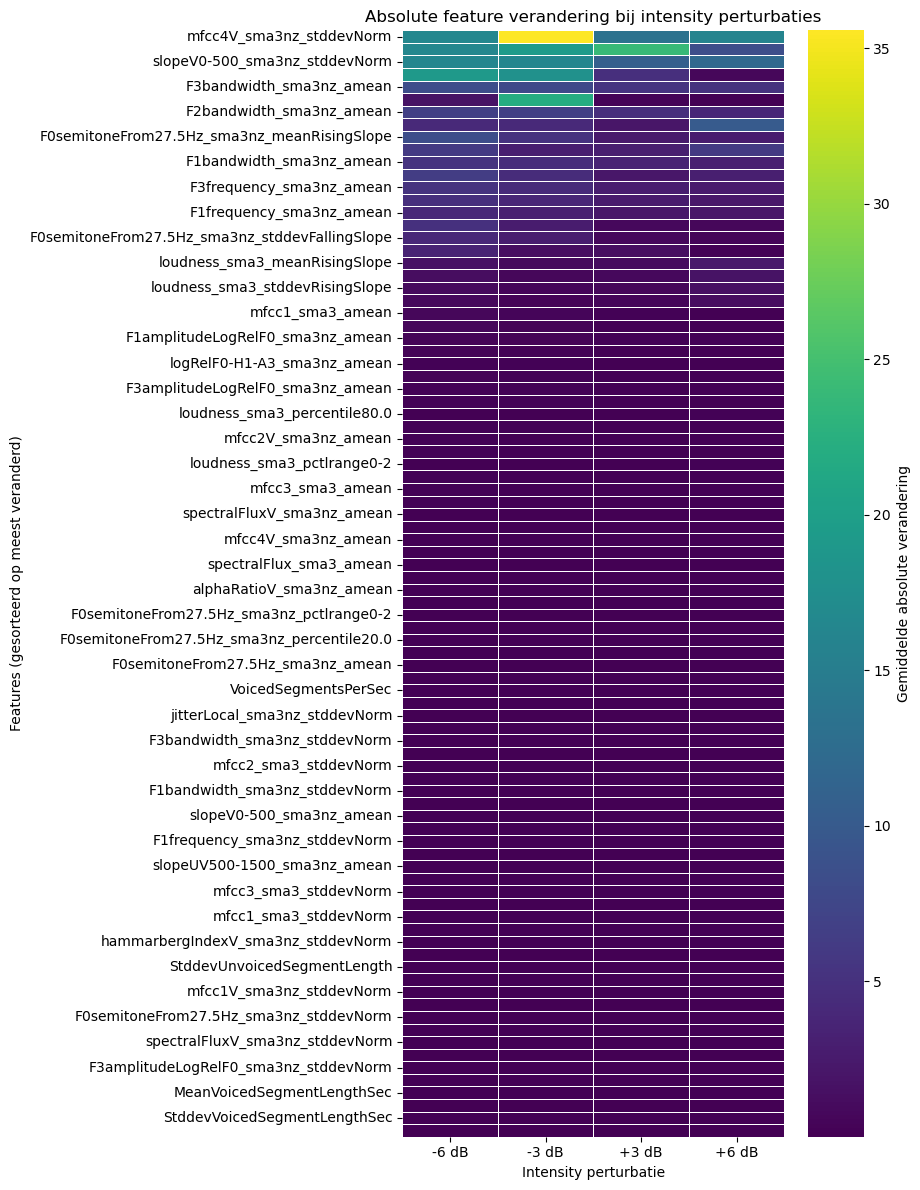

In [21]:
# Standard libraries
from pathlib import Path
import os
from matplotlib.colors import Normalize
from pathlib import Path
import subprocess
import pandas as pd
import tempfile
from sklearn.preprocessing import StandardScaler
from scipy.io import wavfile
from scipy.signal import wiener
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# try heatmap with absolute difference (not the one to use)
BASE_PATH = r"C:\Users\marti\Documents\Technical Medicine Master\Stages TM2\TM2-3\Technische opdracht"

files = {
    "original": os.path.join(BASE_PATH, "opensmile_wiener_features_pain.csv"),
    "-6 dB": os.path.join(BASE_PATH, "opensmile_intensity_-6dB_features_pain.csv"),
    "-3 dB": os.path.join(BASE_PATH, "opensmile_intensity_-3dB_features_pain.csv"),
    "+3 dB": os.path.join(BASE_PATH, "opensmile_intensity_3dB_features_pain.csv"),
    "+6 dB": os.path.join(BASE_PATH, "opensmile_intensity_6dB_features_pain.csv"),
}


#load data in dataframe
dfs = {k: pd.read_csv(v) for k, v in files.items()}

for k in dfs:
    dfs[k] = dfs[k].sort_values(by=["participant_id", "filename"]).reset_index(drop=True)

reference_ids = dfs["original"][["participant_id", "filename"]]

for key in ["-6 dB", "-3 dB", "+3 dB", "+6 dB"]:
    if not reference_ids.equals(dfs[key][["participant_id", "filename"]]):
        raise ValueError(f"Mismatch in {key}")


# identification of feature columns
exclude_cols = ["participant_id", "filename", "file_path", "name"]
numeric_cols = dfs["original"].select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [col for col in numeric_cols if col not in exclude_cols]


# absolute difference
abs_diff_means = {}

original_features = dfs["original"][feature_cols]

for condition in ["-6 dB", "-3 dB", "+3 dB", "+6 dB"]:
    perturbed_features = dfs[condition][feature_cols]

    abs_diff = np.abs(perturbed_features - original_features)

    abs_diff_means[condition] = abs_diff.mean(axis=0) #mean for the rows (files)


# dataframe for heatmap
heatmap_df = pd.DataFrame(abs_diff_means)

heatmap_df["mean_change"] = heatmap_df.mean(axis=1)
heatmap_df = heatmap_df.sort_values(by="mean_change", ascending=False)
heatmap_df = heatmap_df.drop(columns=["mean_change"])

top_n = 88
heatmap_top = heatmap_df.head(top_n)


# heatmap
plt.figure(figsize=(9, 12))

sns.heatmap(
    heatmap_top,
    cmap="viridis",
    linewidths=0.4,
    linecolor="white",
    cbar_kws={"label": "Gemiddelde absolute verandering"},
    annot=False
)

plt.title("Absolute feature verandering bij intensity perturbaties")
plt.xlabel("Intensity perturbatie")
plt.ylabel("Features (gesorteerd op meest veranderd)")
plt.tight_layout()
plt.show()


Robustness evaluation with standardisation on Wiener Filtered audio, with StandardScaler (the one to use)

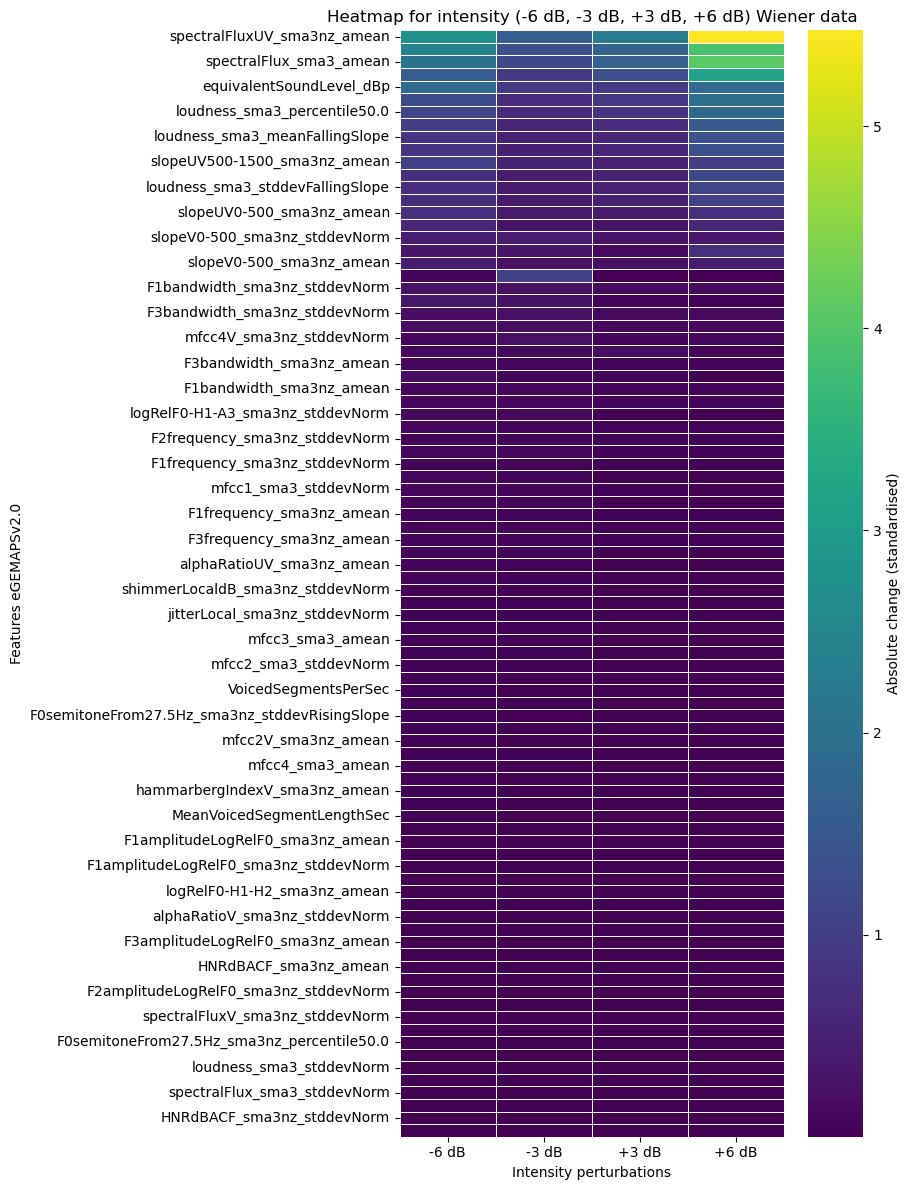

In [22]:
BASE_PATH = r"C:\Users\marti\Documents\Technical Medicine Master\Stages TM2\TM2-3\Technische opdracht"

files = {
    "original": os.path.join(BASE_PATH, "opensmile_wiener_features_pain.csv"),
    "-6 dB": os.path.join(BASE_PATH, "opensmile_intensity_-6dB_features_pain.csv"),
    "-3 dB": os.path.join(BASE_PATH, "opensmile_intensity_-3dB_features_pain.csv"),
    "+3 dB": os.path.join(BASE_PATH, "opensmile_intensity_3dB_features_pain.csv"),
    "+6 dB": os.path.join(BASE_PATH, "opensmile_intensity_6dB_features_pain.csv"),
}

# data
dfs = {k: pd.read_csv(v) for k, v in files.items()}

for k in dfs:
    dfs[k] = dfs[k].sort_values(by=["participant_id", "filename"]).reset_index(drop=True)

reference_ids = dfs["original"][["participant_id", "filename"]]

for key in ["-6 dB", "-3 dB", "+3 dB", "+6 dB"]:
    if not reference_ids.equals(dfs[key][["participant_id", "filename"]]):
        raise ValueError(f"Mismatch in {key}")

# features
exclude_cols = ["participant_id", "filename", "file_path", "name"]
numeric_cols = dfs["original"].select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [col for col in numeric_cols if col not in exclude_cols]

#standardisation with sklearn
# fit the scaler on the original data
scaler = StandardScaler()
scaler.fit(dfs["original"][feature_cols])
dfs_std = {}

for key, df in dfs.items():
    df_std = df.copy()
    df_std_features = scaler.transform(df[feature_cols]) # apply the same transformation also to the perturbated data (-3 dB, +3 dB, etc.)
    df_std[feature_cols] = df_std_features
    dfs_std[key] = df_std

# Absolute difference with standardised features
abs_diff_means = {}
original_features = dfs_std["original"][feature_cols]

for condition in ["-6 dB", "-3 dB", "+3 dB", "+6 dB"]:
    perturbed_features = dfs_std[condition][feature_cols]

    abs_diff = np.abs(perturbed_features - original_features)
    abs_diff_means[condition] = abs_diff.mean(axis=0)

# heatmap
heatmap_df = pd.DataFrame(abs_diff_means)

heatmap_df["mean_change"] = heatmap_df.mean(axis=1)
heatmap_df = heatmap_df.sort_values(by="mean_change", ascending=False)
heatmap_df = heatmap_df.drop(columns=["mean_change"])

top_n = 88  # all features
heatmap_top = heatmap_df.head(top_n)

plt.figure(figsize=(9, 12))
sns.heatmap(
    heatmap_top,
    cmap="viridis",
    linewidths=0.4,
    linecolor="white",
    cbar_kws={"label": "Absolute change (standardised)"},
    annot=False
)

plt.title("Heatmap for intensity (-6 dB, -3 dB, +3 dB, +6 dB) Wiener data")
plt.xlabel("Intensity perturbations")
plt.ylabel("Features eGEMAPSv2.0")
plt.tight_layout()
plt.show()

Heatmap for Gaussian Noise, with wiener data + standardisation

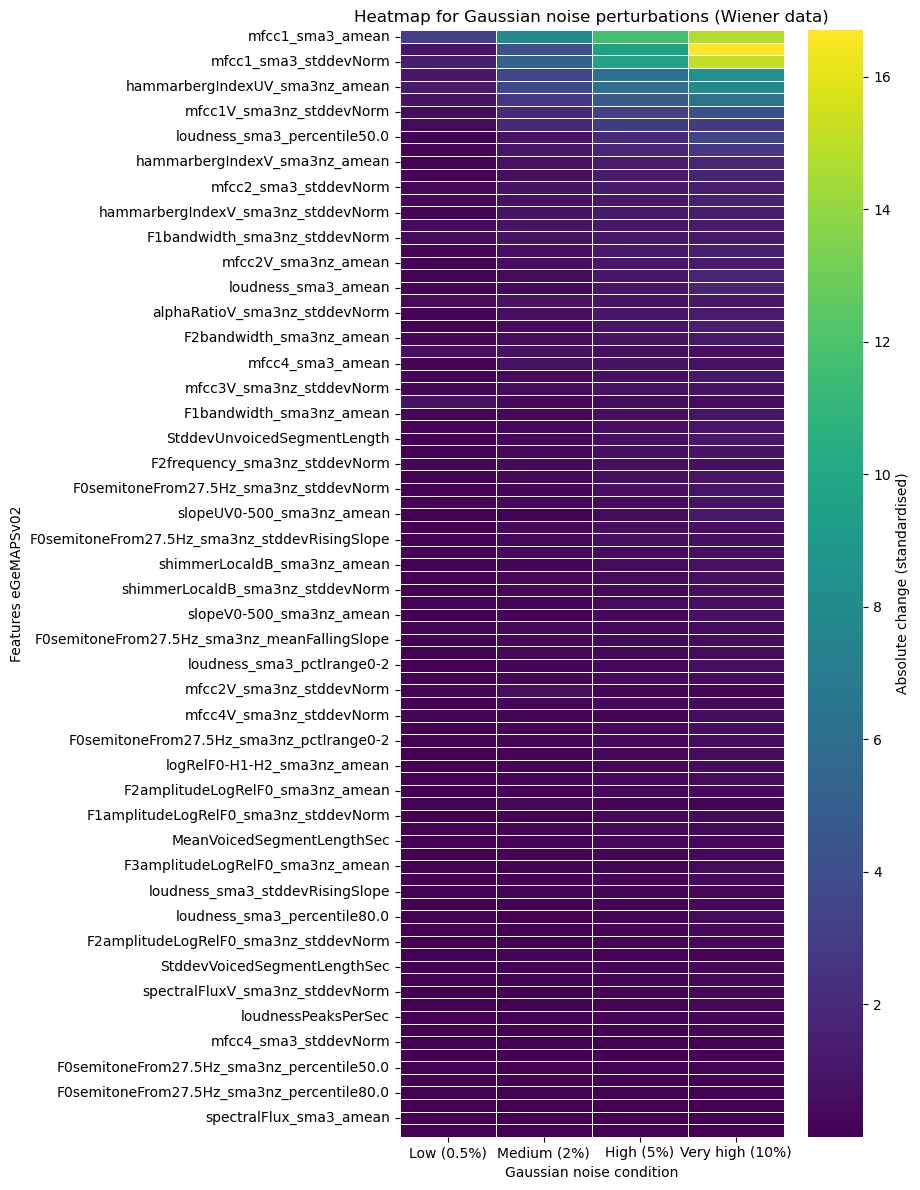

In [23]:
BASE_PATH = r"C:\Users\marti\Documents\Technical Medicine Master\Stages TM2\TM2-3\Technische opdracht"

files = {
    "original": os.path.join(BASE_PATH, "opensmile_wiener_features_pain.csv"),
    "low_gaussian_noise": os.path.join(BASE_PATH, "opensmile_low_gaussian_features_pain.csv"),
    "medium_gaussian_noise": os.path.join(BASE_PATH, "opensmile_medium_gaussian_features_pain.csv"),
    "high_gaussian_noise": os.path.join(BASE_PATH, "opensmile_high_gaussian_features_pain.csv"),
    "very_high_gaussian_noise": os.path.join(BASE_PATH, "opensmile_very_high_gaussian_features_pain.csv"),
}

# data 
dfs = {k: pd.read_csv(v) for k, v in files.items()}

# sort so rows match
for k in dfs:
    dfs[k] = dfs[k].sort_values(by=["participant_id", "filename"]).reset_index(drop=True)

# check 
reference_ids = dfs["original"][["participant_id", "filename"]]

for key in ["low_gaussian_noise", "medium_gaussian_noise", "high_gaussian_noise", "very_high_gaussian_noise"]:
    if not reference_ids.equals(dfs[key][["participant_id", "filename"]]):
        raise ValueError(f"Mismatch in {key}")

# feature columns 
exclude_cols = ["participant_id", "filename", "file_path", "name"]
numeric_cols = dfs["original"].select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [col for col in numeric_cols if col not in exclude_cols]

# standardise 
scaler = StandardScaler()
scaler.fit(dfs["original"][feature_cols])

dfs_std = {}
for key, df in dfs.items():
    df_std = df.copy()
    df_std[feature_cols] = scaler.transform(df[feature_cols])
    dfs_std[key] = df_std

# absolute diff 
abs_diff_means = {}
original_features = dfs_std["original"][feature_cols]

for condition in ["low_gaussian_noise", "medium_gaussian_noise", "high_gaussian_noise", "very_high_gaussian_noise"]:
    perturbed_features = dfs_std[condition][feature_cols]
    abs_diff = np.abs(perturbed_features - original_features)
    abs_diff_means[condition] = abs_diff.mean(axis=0)

# heatmap dataframe 
heatmap_df = pd.DataFrame(abs_diff_means)

heatmap_df["mean_change"] = heatmap_df.mean(axis=1)
heatmap_df = heatmap_df.sort_values(by="mean_change", ascending=False)
heatmap_df = heatmap_df.drop(columns=["mean_change"])
rename_dict = {
    "low_gaussian_noise": "Low (0.5%)",
    "medium_gaussian_noise": "Medium (2%)",
    "high_gaussian_noise": "High (5%)",
    "very_high_gaussian_noise": "Very high (10%)"
}

heatmap_df = heatmap_df.rename(columns=rename_dict)

top_n = 88
heatmap_top = heatmap_df.head(top_n)

# plot 
plt.figure(figsize=(9, 12))
sns.heatmap(
    heatmap_top,
    cmap="viridis",
    linewidths=0.4,
    linecolor="white",
    cbar_kws={"label": "Absolute change (standardised)"},
    annot=False
)

plt.title("Heatmap for Gaussian noise perturbations (Wiener data)")
plt.xlabel("Gaussian noise condition")
plt.ylabel("Features eGeMAPSv02")
plt.tight_layout()
plt.show()

Pink noise 

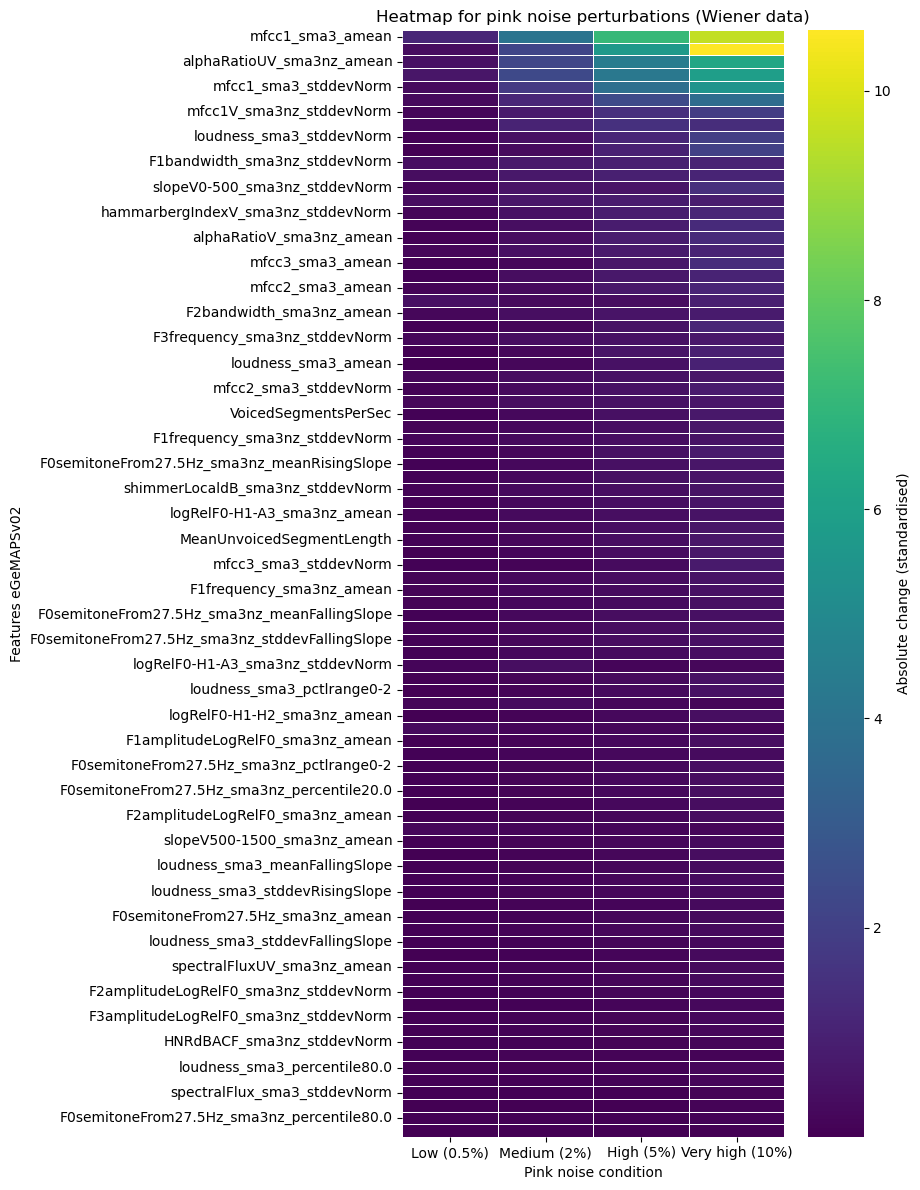

In [24]:
BASE_PATH = r"C:\Users\marti\Documents\Technical Medicine Master\Stages TM2\TM2-3\Technische opdracht"

files = {
    "original": os.path.join(BASE_PATH, "opensmile_wiener_features_pain.csv"),
    "low_pink_noise": os.path.join(BASE_PATH, "opensmile_low_pink_features_pain.csv"),
    "medium_pink_noise": os.path.join(BASE_PATH, "opensmile_medium_pink_features_pain.csv"),
    "high_pink_noise": os.path.join(BASE_PATH, "opensmile_high_pink_features_pain.csv"),
    "very_high_pink_noise": os.path.join(BASE_PATH, "opensmile_very_high_pink_features_pain.csv"),
}

# data inladen
dfs = {k: pd.read_csv(v) for k, v in files.items()}

# sort so rows match
for k in dfs:
    dfs[k] = dfs[k].sort_values(by=["participant_id", "filename"]).reset_index(drop=True)

# check     
reference_ids = dfs["original"][["participant_id", "filename"]]

for key in ["low_pink_noise", "medium_pink_noise", "high_pink_noise", "very_high_pink_noise"]:
    if not reference_ids.equals(dfs[key][["participant_id", "filename"]]):
        raise ValueError(f"Mismatch in {key}")

# feature columns 
exclude_cols = ["participant_id", "filename", "file_path", "name"]
numeric_cols = dfs["original"].select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [col for col in numeric_cols if col not in exclude_cols]

# standardise 
scaler = StandardScaler()
scaler.fit(dfs["original"][feature_cols])

dfs_std = {}
for key, df in dfs.items():
    df_std = df.copy()
    df_std[feature_cols] = scaler.transform(df[feature_cols])
    dfs_std[key] = df_std

# absolute differences 
abs_diff_means = {}
original_features = dfs_std["original"][feature_cols]

for condition in ["low_pink_noise", "medium_pink_noise", "high_pink_noise", "very_high_pink_noise"]:
    perturbed_features = dfs_std[condition][feature_cols]
    abs_diff = np.abs(perturbed_features - original_features)
    abs_diff_means[condition] = abs_diff.mean(axis=0)

# heatmap dataframe 
heatmap_df = pd.DataFrame(abs_diff_means)

heatmap_df["mean_change"] = heatmap_df.mean(axis=1)
heatmap_df = heatmap_df.sort_values(by="mean_change", ascending=False)
heatmap_df = heatmap_df.drop(columns=["mean_change"])

# columns names 
rename_dict = {
    "low_pink_noise": "Low (0.5%)",
    "medium_pink_noise": "Medium (2%)",
    "high_pink_noise": "High (5%)",
    "very_high_pink_noise": "Very high (10%)"
}
heatmap_df = heatmap_df.rename(columns=rename_dict)

top_n = 88
heatmap_top = heatmap_df.head(top_n)

# heatmap 
plt.figure(figsize=(9, 12))
sns.heatmap(
    heatmap_top,
    cmap="viridis",
    linewidths=0.4,
    linecolor="white",
    cbar_kws={"label": "Absolute change (standardised)"},
    annot=False
)

plt.title("Heatmap for pink noise perturbations (Wiener data)")
plt.xlabel("Pink noise condition")
plt.ylabel("Features eGeMAPSv02")
plt.tight_layout()
plt.show()

Low pass filter 

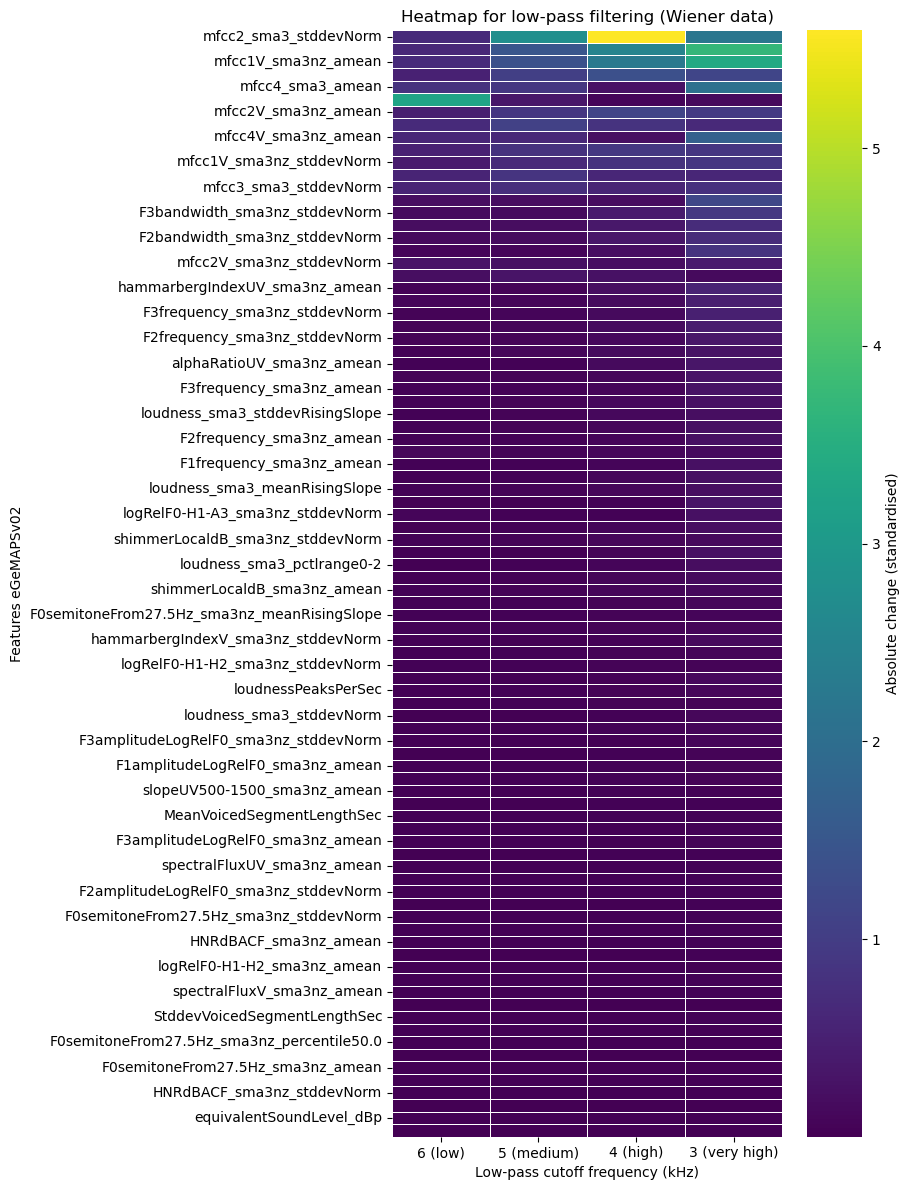

In [26]:
BASE_PATH = r"C:\Users\marti\Documents\Technical Medicine Master\Stages TM2\TM2-3\Technische opdracht"

files = {
    "original": os.path.join(BASE_PATH, "opensmile_wiener_features_pain.csv"),
    "low_lowpass": os.path.join(BASE_PATH, "opensmile_low_lowpass_features_pain.csv"),
    "medium_lowpass": os.path.join(BASE_PATH, "opensmile_medium_lowpass_features_pain.csv"),
    "high_lowpass": os.path.join(BASE_PATH, "opensmile_high_lowpass_features_pain.csv"),
    "very_high_lowpass": os.path.join(BASE_PATH, "opensmile_very_high_lowpass_features_pain.csv"),
}

# data inladen
dfs = {k: pd.read_csv(v) for k, v in files.items()}

# sort columns so that rows match
for k in dfs:
    dfs[k] = dfs[k].sort_values(by=["participant_id", "filename"]).reset_index(drop=True)

# controleren of koppeling klopt
reference_ids = dfs["original"][["participant_id", "filename"]]

for key in ["low_lowpass", "medium_lowpass", "high_lowpass", "very_high_lowpass"]:
    if not reference_ids.equals(dfs[key][["participant_id", "filename"]]):
        raise ValueError(f"Mismatch in {key}")

# feature columns 
exclude_cols = ["participant_id", "filename", "file_path", "name"]
numeric_cols = dfs["original"].select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [col for col in numeric_cols if col not in exclude_cols]

# Standardise 
scaler = StandardScaler()
scaler.fit(dfs["original"][feature_cols])

dfs_std = {}
for key, df in dfs.items():
    df_std = df.copy()
    df_std[feature_cols] = scaler.transform(df[feature_cols])
    dfs_std[key] = df_std

# absolute difference
abs_diff_means = {}
original_features = dfs_std["original"][feature_cols]

for condition in ["low_lowpass", "medium_lowpass", "high_lowpass", "very_high_lowpass"]:
    perturbed_features = dfs_std[condition][feature_cols]
    abs_diff = np.abs(perturbed_features - original_features)
    abs_diff_means[condition] = abs_diff.mean(axis=0)

# dataframe
heatmap_df = pd.DataFrame(abs_diff_means)

heatmap_df["mean_change"] = heatmap_df.mean(axis=1)
heatmap_df = heatmap_df.sort_values(by="mean_change", ascending=False)
heatmap_df = heatmap_df.drop(columns=["mean_change"])

# Labels
rename_dict = {
    "low_lowpass": "6 (low)",
    "medium_lowpass": "5 (medium)",
    "high_lowpass": "4 (high)",
    "very_high_lowpass": "3 (very high)"
}
heatmap_df = heatmap_df.rename(columns=rename_dict)

top_n = 88
heatmap_top = heatmap_df.head(top_n)

# plot
plt.figure(figsize=(9, 12))
sns.heatmap(
    heatmap_top,
    cmap="viridis",
    linewidths=0.4,
    linecolor="white",
    cbar_kws={"label": "Absolute change (standardised)"},
    annot=False
)

plt.title("Heatmap for low-pass filtering (Wiener data)")
plt.xlabel("Low-pass cutoff frequency (kHz)")
plt.ylabel("Features eGeMAPSv02")
plt.tight_layout()
plt.show()